In [1]:
import sys
sys.path.append("../Holistic-Explainer/")
from test_dataset_BPR import get_eval_dataset_loader
from data_utils import *

In [2]:
import bert_score
from bert_score import BERTScorer
import numpy as np
import pickle
from tqdm import tqdm

/home/sairamv/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/sairamv/anaconda3/lib/python3.8/site-packages/setuptools/distutils_patch.py:25: UserWarning: Distutils was imported before Setuptools. This usage is discouraged and may exhibit undesirable behaviors or errors. Please use Setuptools' objects directly or at least import Setuptools first.
  warnings.warn(


In [3]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

# Example

In [4]:
DATASET = 'yelp'

In [5]:
EXPL_PATH = '../Holistic-Explainer/generated-expls/'

In [6]:
DATA_PATH = "../data/"

In [7]:
datamaps = load_json("../data/{}/datamaps.json".format(DATASET))
print(datamaps.keys())

dict_keys(['user2id', 'item2id', 'id2user', 'id2item', 'attribute2id', 'id2attribute'])


In [8]:
user_num = len(datamaps['user2id'])
item_num = len(datamaps['item2id'])
targetItems = readTargetItem(os.path.join(DATA_PATH, DATASET, "targetItems.txt"))

In [9]:
meta_data = load_pickle(os.path.join(DATA_PATH, DATASET, 'meta_data.pkl'))
meta_dict = {}
for i, meta_item in enumerate(meta_data):
    meta_dict[meta_item['business_id']] = i

In [10]:
rev_data = load_pickle("../data/{}/review_splits.pkl".format(DATASET))
rev_data.keys()

dict_keys(['train', 'val', 'test', 'train_indices', 'val_indices', 'test_indices'])

In [11]:
reviews = rev_data['train'] + rev_data['val'] + rev_data['test']
len(reviews)

316354

In [12]:
rev_dict = {}
for review in reviews:
    user_name, item_name = review['reviewerID'], review['asin']
    rev_dict[(user_name, item_name)] = review
len(rev_dict)

304524

In [13]:
reviews[0]

{'review_id': 'tuNJg57DIbe8G9ZOKiJ4bA',
 'useful': 0,
 'funny': 0,
 'cool': 0,
 'date': '2019-02-23 08:33:06',
 'unixReviewTime': '20190223083306',
 'reviewerID': 'pGvCyc6xVOyoxeIDgafCCQ',
 'asin': '5eV8oUGdBXylwB7HeaDFOA',
 'overall': 4.0,
 'reviewText': 'I tried the steak entree plate that came with a side salad, pita bread, 2 skewers of steak, and their yogurt sauce (forgot the name). \n\nI think my first mistake was that I order the steak "well done" as I hate raw steak but I hadn\'t realized that it was sirloin steak. The steak was chewy and honestly I almost choked on it. The side salad and it\'s dressing was really good except I bit into an olive not knowing there was a seed in it! Good thing I didn\'t break my tooth! \n\nThe food was just okay. \n\nOn the other hand, I order a piece of baklava and oohhh my goodness gracious, I\'m not even a sweets lover, but dayum this dessert was top notch! The top was flaky and as you got to the bottom of the piece it would get more and more 

In [14]:
expls = load_pickle(os.path.join(EXPL_PATH, DATASET, "train.pkl"))

In [15]:
_, eval_dataset = get_eval_dataset_loader(datamaps = datamaps, 
                                                    targetItems = targetItems, 
                                                    user_num = user_num, 
                                                    item_num = item_num, 
                                                    mode='test',
                                                    batch_size=100, 
                                                    dataset = DATASET, 
                                                    data_path = DATA_PATH, 
                                                    expls = expls, 
                                                    workers=0, 
                                                    shuffle=False)

[INFO] Mode: test, Dataset Size: 3043100, DataLoader Size: 30431


In [16]:
val_items = eval_dataset.get_val_items()

In [17]:
len(val_items)

30431

In [18]:
list(val_items.items())[0]

(0, 55)

In [19]:
user_id, item_id =  list(val_items.items())[0]

In [20]:
expls[(user_id, item_id)]

{'pos-expl': 'The customer visited this business because they wanted to enjoy a night out at the Galaxy Green Valley Luxury + Theatre, which they had been planning since their last visit to the resort spa.',
 'neg-expl': 'The customer did not visit this business because they have been experiencing health issues that make it difficult for them to travel long distances or engage in physically demanding activities.',
 'label': 1,
 'target_item': '"Galaxy Green Valley Luxury + Theatre"'}

In [21]:
user_name = datamaps['id2user'][str(user_id + 1)]

In [22]:
item_name = datamaps['id2item'][str(item_id)]

In [23]:
rev_dict[(user_name,item_name)]

{'review_id': '73CgVR9no55clilQNpPnWw',
 'useful': 0,
 'funny': 0,
 'cool': 0,
 'date': '2019-10-25 21:03:28',
 'unixReviewTime': '20191025210328',
 'reviewerID': 'Donht4mLJ4aO4FQhqHGJtw',
 'asin': 'zoODlH40edpJYLPLkHilNA',
 'overall': 5.0,
 'reviewText': 'A very cool theater that is all about kicking back! Literally!! Here to see the Zombieland sequel! Should that be two words?!? Double Tap! Whatever! Anyways the film doesn\'t begin until 2:10. It is presently 1:46! At this theater you can almost turn your chair into a bed w/ table & drink holder! Crazy how nice theaters have become! When I was a kid most theaters were shitholes! The floor was where the trash went. Your shoes were always "stuck" to the floor! I loved the first Zombieland plus I am a fan of all the film\'s actors! It\'s now 1:53! Guess I should have a lot more written, but I have to keep going back and correcting my mistakes! Damnit!! This theater is immaculately clean! I\'m almost apprehensive about opening my popcorn

In [24]:
meta_data[meta_dict[item_name]]

{'business_id': 'zoODlH40edpJYLPLkHilNA',
 'name': 'Galaxy Green Valley Luxury + Theatre',
 'address': '4500 E Sunset Rd, Unit 10',
 'city': 'Henderson',
 'state': 'NV',
 'postal_code': '89014',
 'latitude': 36.0719076187,
 'longitude': -115.0765573934,
 'stars': 4.0,
 'review_count': 832,
 'is_open': 1,
 'attributes': {'DogsAllowed': 'False',
  'GoodForKids': 'True',
  'RestaurantsAttire': "u'casual'",
  'WiFi': "u'no'",
  'ByAppointmentOnly': 'False'},
 'categories': 'Arts & Entertainment, Cinema',
 'hours': {'Monday': '11:30-23:30',
  'Tuesday': '11:30-23:30',
  'Wednesday': '11:30-23:30',
  'Thursday': '11:30-23:30',
  'Friday': '11:30-23:30',
  'Saturday': '11:30-23:30',
  'Sunday': '11:30-23:30'}}

In [25]:
expls_all = {}
for pair in list(val_items.items())[:]:
    user_id, item_id = pair
    user_name = datamaps['id2user'][str(user_id + 1)]
    item_name = datamaps['id2item'][str(item_id)]
    rev_info = rev_dict[(user_name,item_name)]
    expl_info = expls[pair]
    meta_info = meta_data[meta_dict[item_name]]
    expls_all[pair] = expl_info
    expls_all[pair].update(rev_info)
    expls_all[pair].update(meta_info)

len(expls_all)

30431

In [26]:
expls_all[pair]

{'pos-expl': 'The customer visited this business because they were looking for a safer alternative to traditional dog daycare, which they had previously experienced with another business, resulting in a negative experience that led them to seek a different option.',
 'neg-expl': 'The customer did not visit this business because they were previously a frequent customer at Hot Diggity Dogs but have been absent for an extended period, and after their last visit, they expressed a desire to switch to a different pet-sitting service.',
 'label': 1,
 'target_item': '"Hot Diggity Dog Daycare"',
 'review_id': 'AWhbQ-5hrIb6VQfZLLxPEg',
 'useful': 0,
 'funny': 0,
 'cool': 0,
 'date': '2019-06-20 01:31:42',
 'unixReviewTime': '20190620013142',
 'reviewerID': '1EbB5EpoIE3ge_Vv_VVUDw',
 'asin': 'DHklgMcOIp8oFiQogiH-bQ',
 'overall': 4.0,
 'reviewText': 'Pretty good daycare. My babygirl Charli Mae always have fun & comes home tuckered out!! One minor complaint is that sometimes the camera app is down.

In [27]:
bert_score.score([expls_all[pair]['pos-expl']],[expls_all[pair]['reviewText']],lang='en')

(tensor([0.8439]), tensor([0.8295]), tensor([0.8366]))

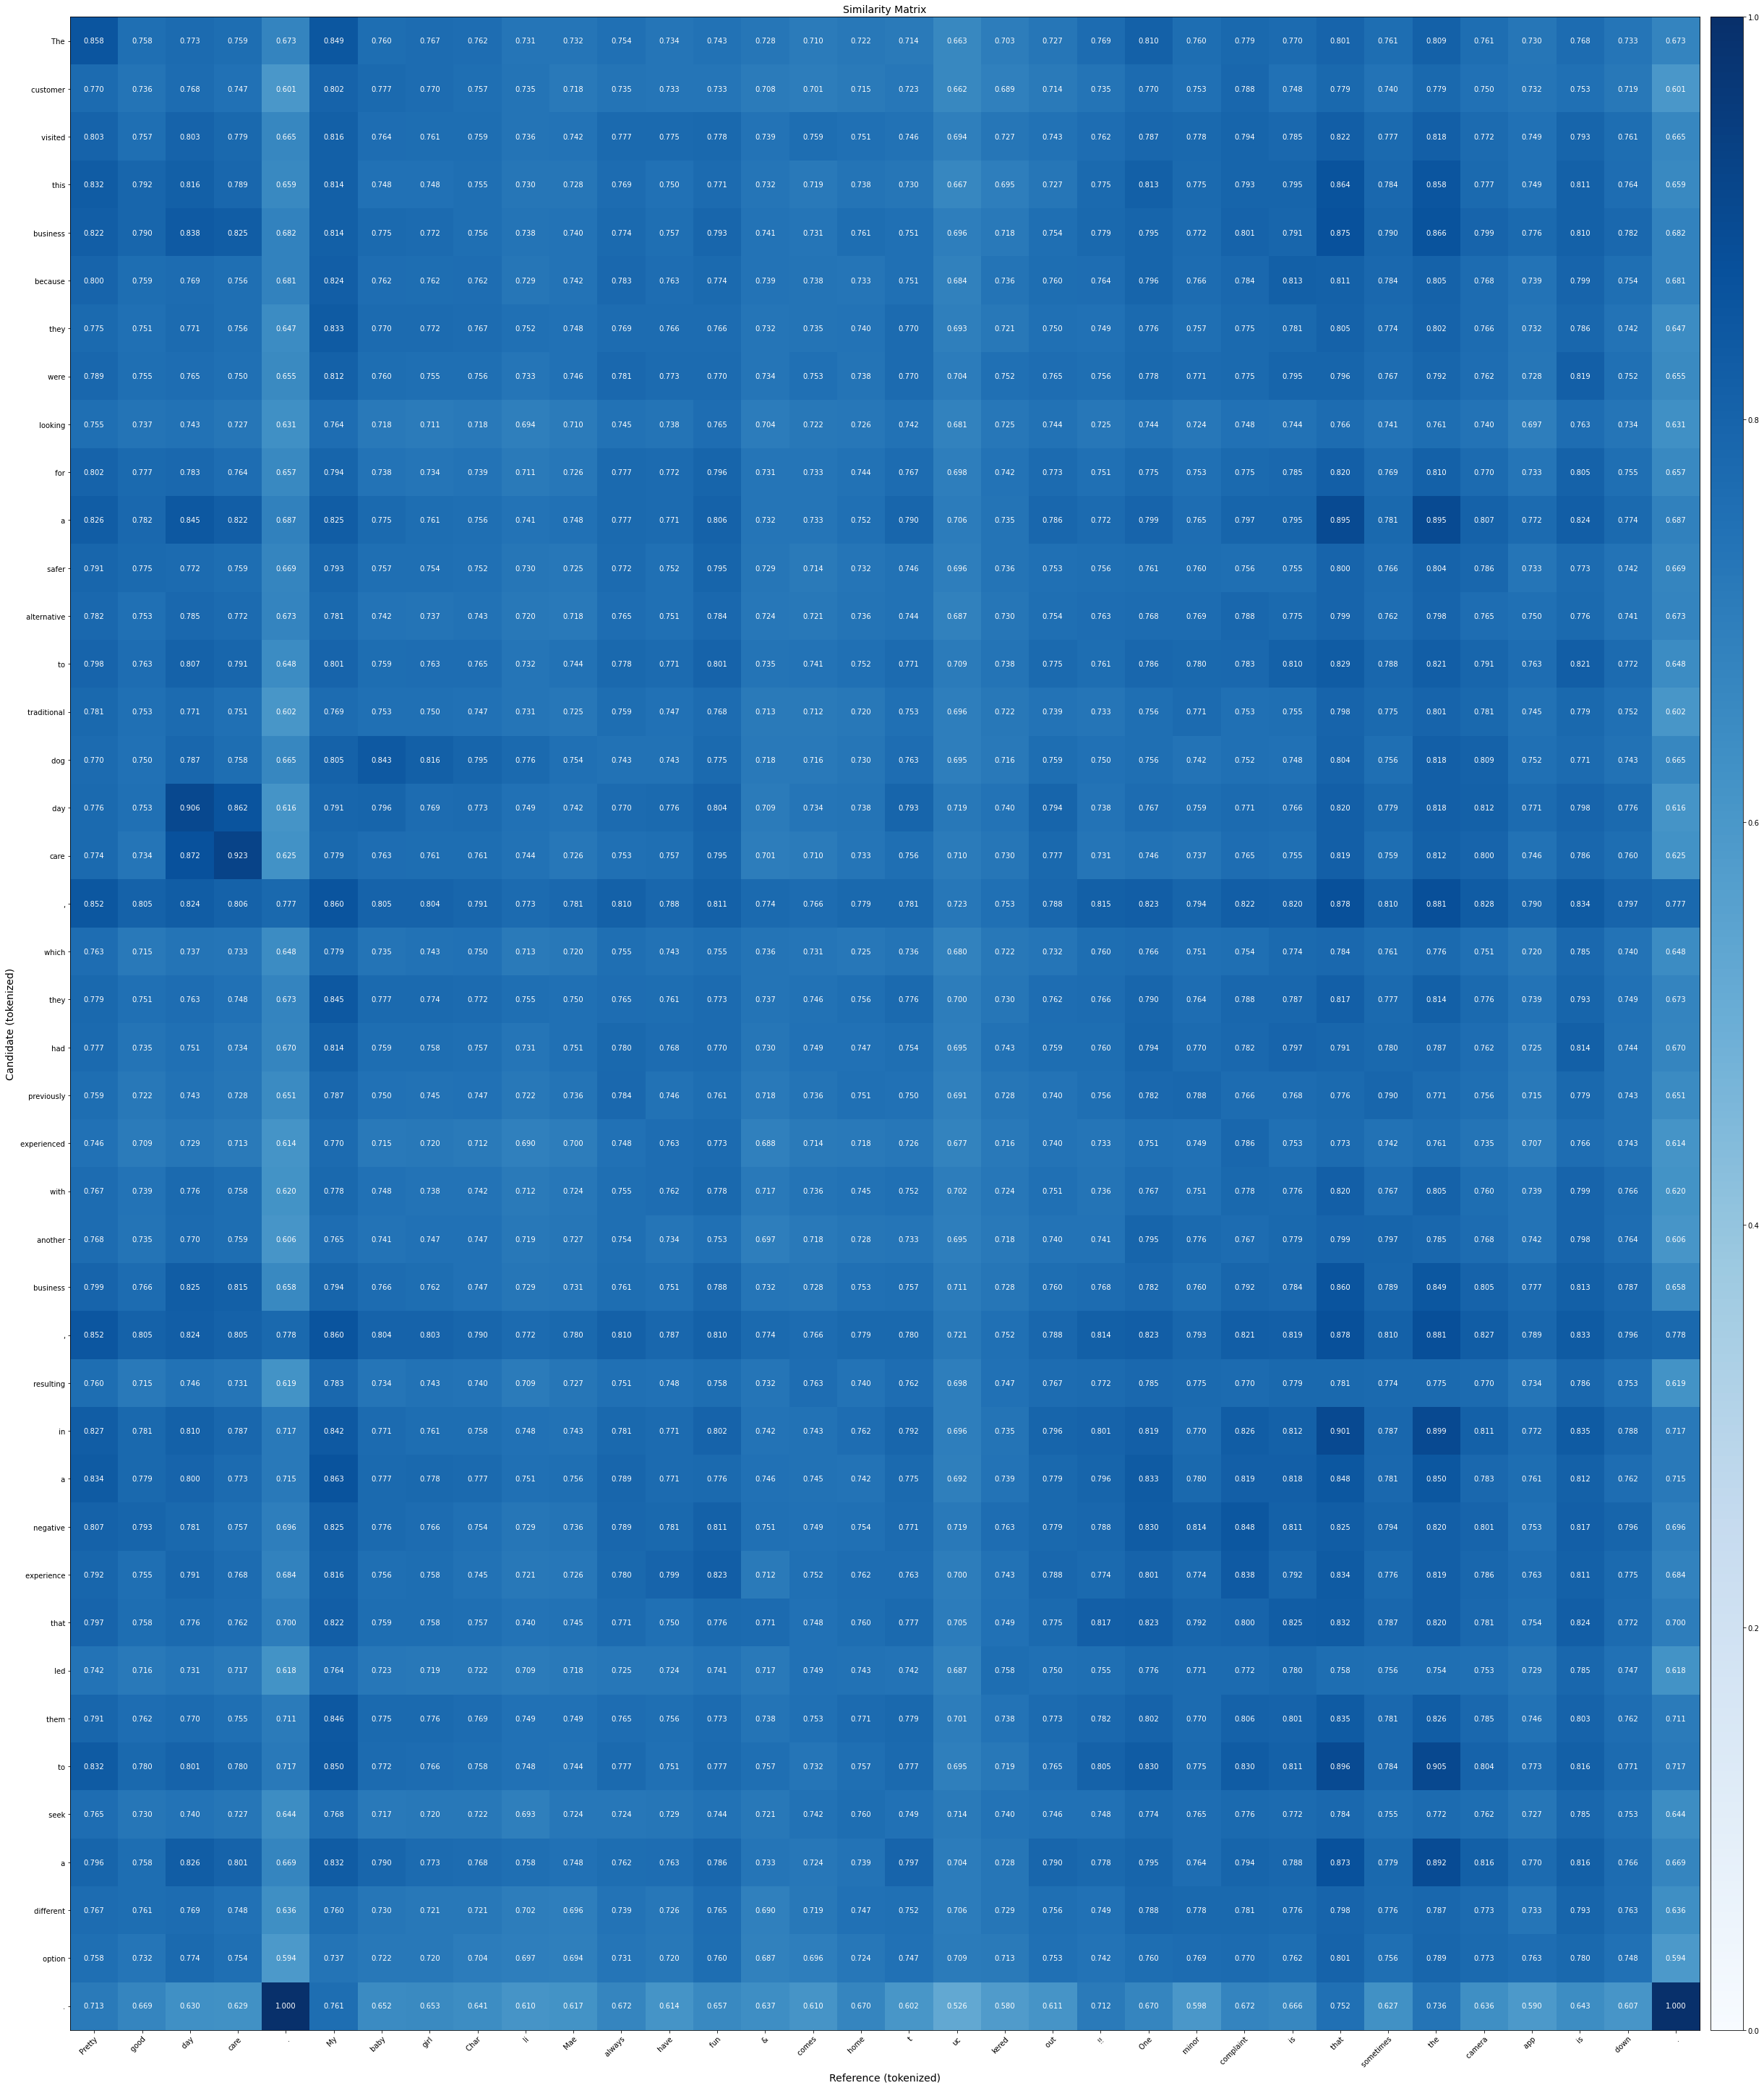

In [28]:
bert_score.plot_example(expls_all[pair]['pos-expl'],expls_all[pair]['reviewText'],lang='en')

In [29]:
bert_score.score([expls_all[pair]['neg-expl']],[expls_all[pair]['reviewText']],lang='en')

(tensor([0.8189]), tensor([0.8225]), tensor([0.8207]))

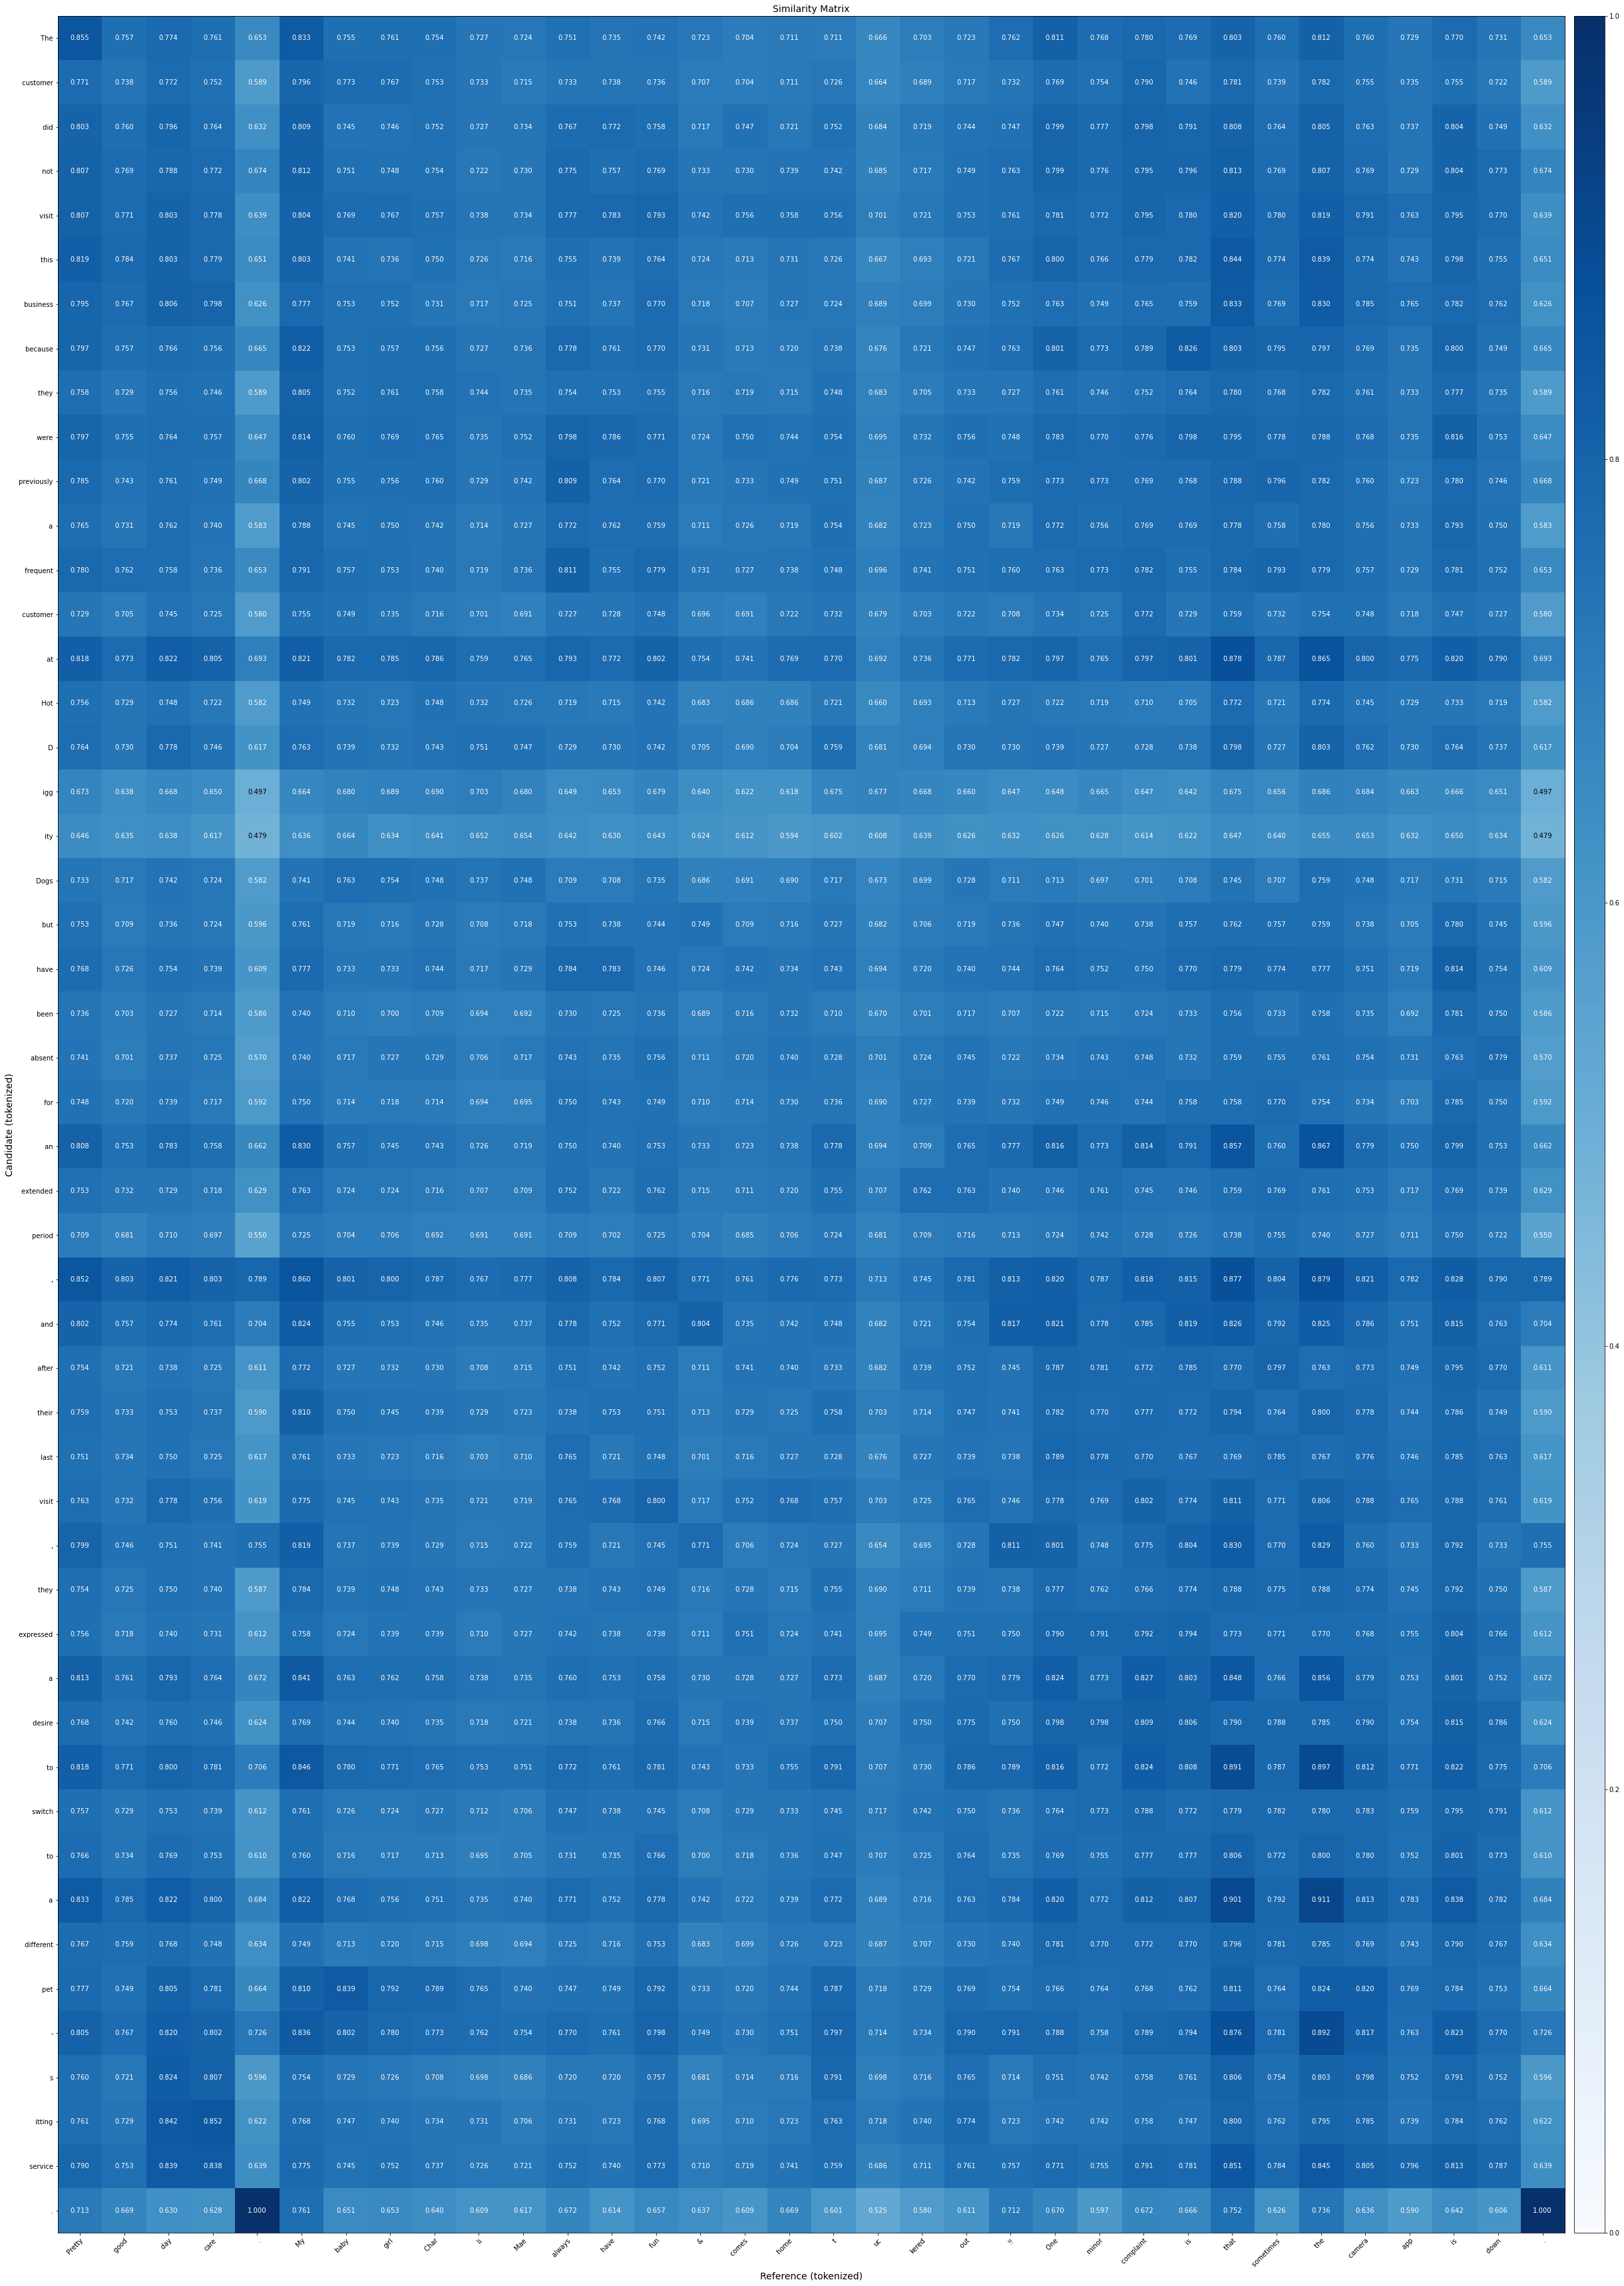

In [30]:
bert_score.plot_example(expls_all[pair]['neg-expl'],expls_all[pair]['reviewText'],lang='en')

# Evaluate

In [31]:
# ---------------------------------------------------------
# Helper function to print stats
# ---------------------------------------------------------
def bootstrap_ci(arr, num_samples=1000, ci=0.95):
    arr = np.array(arr)
    n = len(arr)
    boot_means = []

    for _ in range(num_samples):
        sample = np.random.choice(arr, size=n, replace=True)
        boot_means.append(sample.mean())

    lower = np.percentile(boot_means, (1-ci)*50)
    upper = np.percentile(boot_means, 100 - (1-ci)*50)
    return lower, upper


def print_stats(name, arr, threshold=None):
    print(f"\n{name} statistics:")
    print("  Count:", len(arr))
    print("  Mean:", arr.mean())
    print("  Std:", arr.std())
    print("  Median:", np.median(arr))
    # 95% CI
    lower, upper = bootstrap_ci(arr)
    print(f"  95% CI: [{lower:.4f}, {upper:.4f}]")

    if threshold is not None:
        print(f"  Low-quality (<{threshold}):", (arr < threshold).mean() * 100, "%")


def evaluate(val_data,col):
    # val_data <-- your validation dictionary
    print(f"Column: {col}")
    scorer = BERTScorer(lang="en")


    P_scores = []
    R_scores = []
    F1_scores = []

    # ---------------------------------------------------------
    # Iterate through validation samples
    # ---------------------------------------------------------
    for i, (key, sample) in tqdm(enumerate(list(val_data.items()))):
#         if i >=5:
#             break

        pos_expl = sample[col]
        gold_review = sample['reviewText']

        # Safety checks
        if not isinstance(pos_expl, str) or not isinstance(gold_review, str):
            continue
        if len(gold_review.strip()) == 0:
            continue

        # ---------------------------------------------------------
        # Compute BERTScore Precision, Recall, F1
        # ---------------------------------------------------------
        P, R, F1 = scorer.score([pos_expl], [gold_review])

        P_scores.append(float(P))
        R_scores.append(float(R))
        F1_scores.append(float(F1))


    # ---------------------------------------------------------
    # Convert to numpy arrays
    # ---------------------------------------------------------
    P_scores  = np.array(P_scores)
    R_scores  = np.array(R_scores)
    F1_scores = np.array(F1_scores)
    print_stats("Precision", P_scores)
    print_stats("Recall",    R_scores)
    print_stats("F1",        F1_scores, threshold=0.45)
    return {"P_scores":P_scores, "R_scores":R_scores, "F1_scores":F1_scores}

In [32]:
positive_metrics = evaluate(expls_all,'pos-expl')

Column: pos-expl


30431it [06:55, 73.24it/s]



Precision statistics:
  Count: 30431
  Mean: 0.8448045935688305
  Std: 0.013891999502699037
  Median: 0.8449965119361877
  95% CI: [0.8447, 0.8450]

Recall statistics:
  Count: 30431
  Mean: 0.8203110249813996
  Std: 0.020594783782192403
  Median: 0.8208341598510742
  95% CI: [0.8201, 0.8205]

F1 statistics:
  Count: 30431
  Mean: 0.8322364449038788
  Std: 0.01406193909503684
  Median: 0.8325307369232178
  95% CI: [0.8321, 0.8324]
  Low-quality (<0.45): 0.0 %


In [33]:
negative_metrics = evaluate(expls_all,'neg-expl')

Column: neg-expl


30431it [07:07, 71.14it/s]



Precision statistics:
  Count: 30431
  Mean: 0.8368896688050482
  Std: 0.012306364353466888
  Median: 0.8370864391326904
  95% CI: [0.8367, 0.8370]

Recall statistics:
  Count: 30431
  Mean: 0.8161393491227057
  Std: 0.01999956671528115
  Median: 0.8166918754577637
  95% CI: [0.8159, 0.8164]

F1 statistics:
  Count: 30431
  Mean: 0.8262582168730782
  Std: 0.013336149388224913
  Median: 0.8265628814697266
  95% CI: [0.8261, 0.8264]
  Low-quality (<0.45): 0.0 %


In [34]:
empty_pair = [pair for pair,sample in expls_all.items() if not isinstance(sample['reviewText'], str)]
empty_pair

[]

In [35]:
empty_pair = [sample for pair,sample in expls_all.items() if len(sample['reviewText'].strip()) == 0]
empty_pair

[]

In [36]:
empty_pair = [pair for pair,sample in expls_all.items() if not isinstance(sample['pos-expl'], str)]
empty_pair

[]

In [37]:
empty_pair = [pair for pair,sample in expls_all.items() if not isinstance(sample['neg-expl'], str)]
empty_pair

[]